In [66]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get TIMIT pandas for metadata

In [126]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/').glob('*.pdpkl'))
df_path = df_paths[:2] # want sets 1 & 2 for now

In [127]:
df_path

[PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_00.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_01.pdpkl')]

In [173]:
meta_df = []
for path in df_path:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [171]:
# pd.concat(meta_df, axis=0)

In [172]:
meta_df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr', 'participant', 'stim_subset'],
      dtype='object')

### Get experimental results csv

In [79]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

results_files = list(results_path.glob("*.csv"))

In [234]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om4/group/mcdermott/user/jfeather/projects/model_metamers/figure_generation_notebooks/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)

set_ix, word, snr, cond, speaker_sex, orig_df_ix = file_name_to_labels(file_name)
print(file_name)
print(f"{word} at {snr} dB snr with {cond} target sex ({speaker_sex}), ds = {set_ix} original ix = {orig_df_ix}")




https://mcdermottlab.mit.edu/mturk_stimuli/imgriff/timit_attentive_listening_task/four_distractor_3dB_snr/set_01_stim_155_cond_4_snr_3_word_288_speaker_f.wav
friends at 3 dB snr with 4 target sex (f), ds = 1 original ix = 155


In [237]:
results_dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(columns={0:"stim_file_name"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth['participant'] = ix
    
    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    results = responses.join(truth)
    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_file_name'].map(file_name_to_labels))
    
    meta_subset = meta_df[meta_df.stim_subset == orig_dataset_ix]
    results['distractor_words'] = meta_subset.loc[results.orig_df_ix, ['distractor_words']].values
    results['distractor_sex'] = meta_subset.loc[results.orig_df_ix, ['distractor_sex']].values

    results_dfs.append(results)

In [238]:
results = pd.concat(results_dfs, axis=0)

#### Process results csv to plotting format

In [239]:
results

,guessed_word,stim_file_name,participant,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex
trial 0,formed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,majority,-6,1,f,2,ssn,ssn
trial 1,other,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,other,0,4,m,294,ssn,ssn
trial 10,related,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,related,-6,ssn,ssn,186,[occurred],m
trial 100,inside,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,inside,3,2,m,362,"[stage, involved, lower, because]",mmmf
trial 101,status,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,status,3,ssn,ssn,54,[things],f
...,...,...,...,...,...,...,...,...,...,...,...
trial 95,technology,https://mcdermottlab.mit.edu/mturk_stimuli/img...,1,1,technology,3,ssn,ssn,369,ssn,ssn
trial 96,don't,https://mcdermottlab.mit.edu/mturk_stimuli/img...,1,1,don't,-3,4,m,320,"[become, seven, passed, forces]",mmmm
trial 97,change,https://mcdermottlab.mit.edu/mturk_stimuli/img...,1,1,exchange,-6,ssn,ssn,181,ssn,ssn
trial 98,names,https://mcdermottlab.mit.edu/mturk_stimuli/img...,1,1,names,3,2,m,237,"[letters, nature]",mf


In [240]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [241]:
results.head()

,guessed_word,stim_file_name,participant,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy
trial 0,formed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,majority,-6,1,f,2,ssn,ssn,0
trial 1,other,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,other,0,4,m,294,ssn,ssn,1
trial 10,related,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,related,-6,ssn,ssn,186,[occurred],m,1
trial 100,inside,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,inside,3,2,m,362,"[stage, involved, lower, because]",mmmf,1
trial 101,status,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,status,3,ssn,ssn,54,[things],f,1


In [242]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

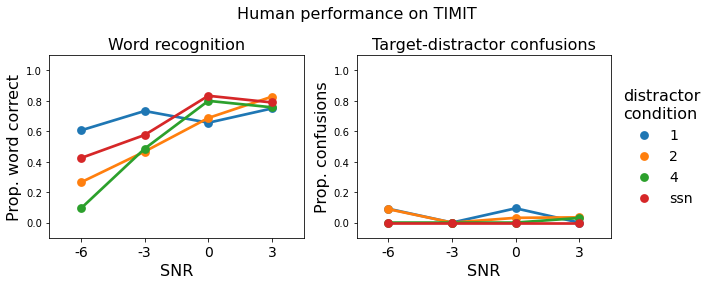

In [243]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Human performance on TIMIT', size=fontsize)
plt.tight_layout()


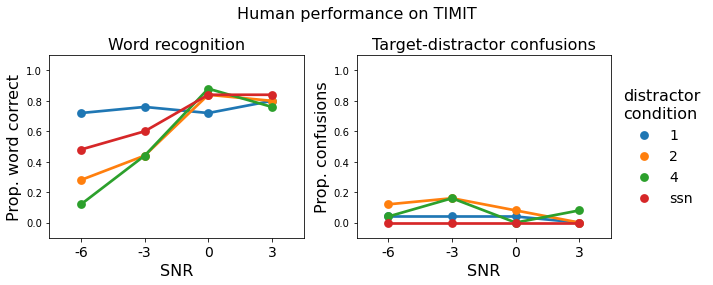

In [40]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Human performance on TIMIT', size=fontsize)
plt.tight_layout()


## Get model results on dataset 00 

In [41]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_dataset_00_MultiDistractorAttnCNN/version_1/')
timit_results = list(parent_path.rglob("*.csv"))

In [42]:
model_results = pd.read_csv(timit_results[0])

In [44]:
model_results.shape

(4120, 3)

In [43]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,step
0,0.0,248.0,0
1,0.0,465.0,1
2,1.0,409.0,2
3,1.0,125.0,3
4,0.0,712.0,4


In [45]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [46]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_all_attn_stim_for_model_eval.pdpkl')

In [47]:
model_meta_df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr', 'dataset'],
      dtype='object')

In [48]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [49]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

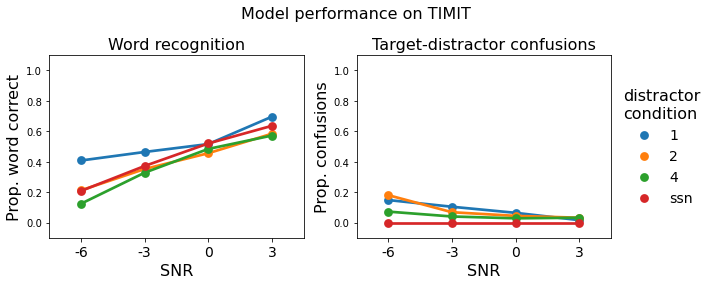

In [50]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=model_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=model_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()


## Put on same plots 

First look at N talkers by SNR for model and human (separate pannels for model and humans)

Then look at single talker accuracy and sinlge talker confusions ( lines for model and human ) 

In [244]:
model_results['subject'] = 'model'
results['subject'] = 'human'

In [245]:
all_results = pd.concat([results, model_results])

In [246]:
all_results.head()

,guessed_word,stim_file_name,participant,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy,confusions,subject,pred_word_ix
trial 0,formed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0.0,0.0,majority,-6,1,f,2,ssn,ssn,0.0,0,human,NaN
trial 1,other,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0.0,0.0,other,0,4,m,294,ssn,ssn,1.0,0,human,NaN
trial 10,related,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0.0,0.0,related,-6,ssn,ssn,186,[occurred],m,1.0,0,human,NaN
trial 100,inside,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0.0,0.0,inside,3,2,m,362,"[stage, involved, lower, because]",mmmf,1.0,0,human,NaN
trial 101,status,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0.0,0.0,status,3,ssn,ssn,54,[things],f,1.0,0,human,NaN


### Error by N Talker 

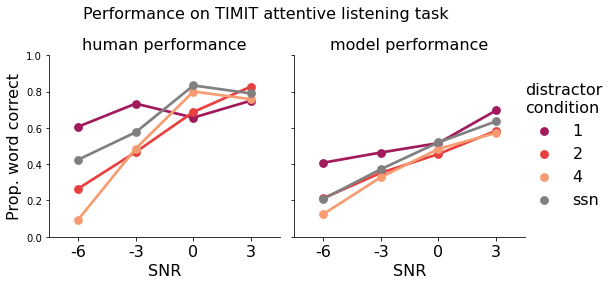

In [247]:
fontsize = 16

snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']

distractor_cmap = sn.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'


g = sn.catplot(kind='point',
    data=all_results,
    x='snr', y='accuracy',
    order = snr_order,
    hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
    col='subject',
    ci=None, seed=1, height=4, aspect=0.75
)

 
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
g.fig.tight_layout()
# g.fig.savefig('../demo_plots/timit_human_v_model.png')

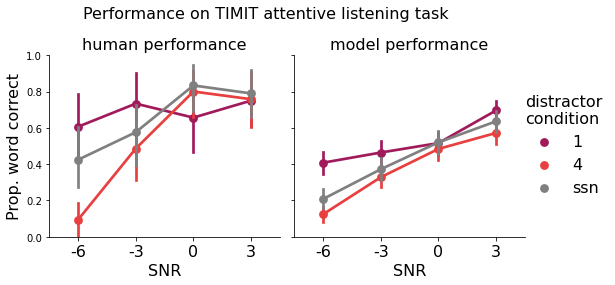

In [250]:
fontsize = 16

snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']

distractor_cmap = sn.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'


g = sn.catplot(kind='point',
    data=all_results,
    x='snr', y='accuracy',
    order = snr_order,
    hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
    col='subject',
    seed=1, height=4, aspect=0.75
)

 
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
g.fig.tight_layout()
# g.fig.savefig('../demo_plots/timit_human_v_model.png')

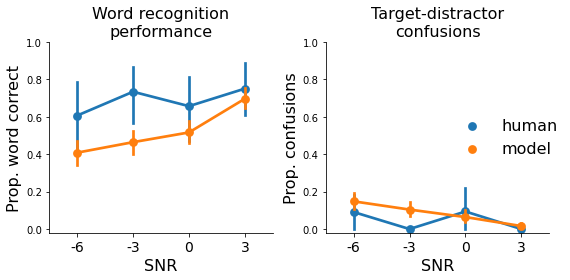

In [251]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=to_plot, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject', height=4,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4,
            ax=axs[1])

axs[0].set_title("Word recognition\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', 
                loc="center right", bbox_to_anchor=(1.1, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()
# plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.png', bbox='inches')

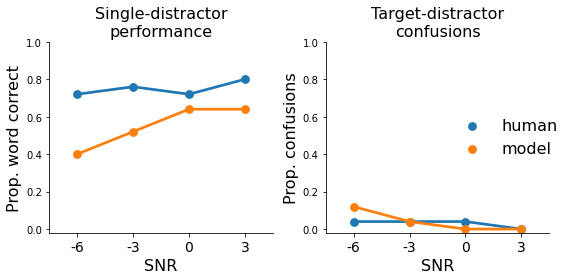

In [64]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=to_plot, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject',  ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Single-distractor\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', 
                loc="center right", bbox_to_anchor=(1.1, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()
plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.png', bbox='inches')

### Scratch code for looking at talker sex similarity 

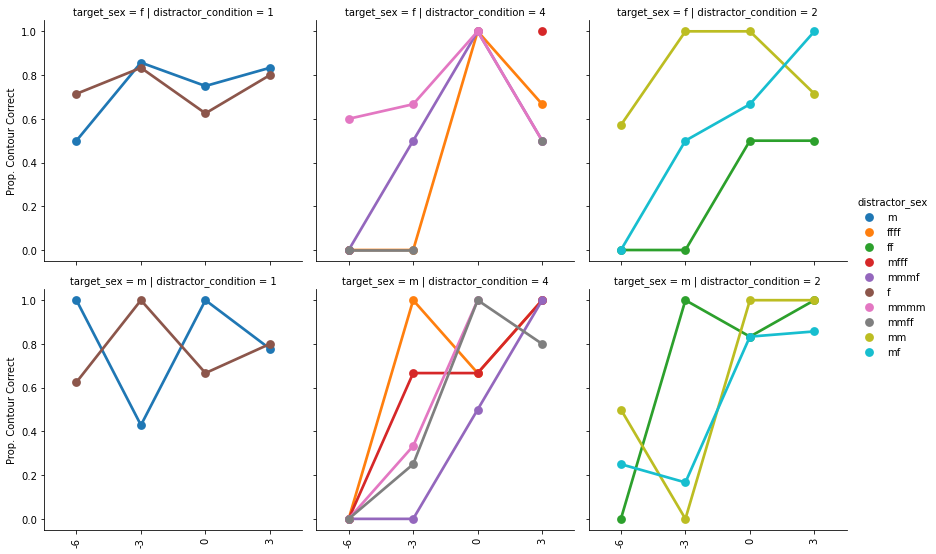

In [116]:
talker_hue_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']
g = sn.catplot( kind='point',
    data=results[results['distractor_condition'].isin(talker_hue_order)], 
    x='snr', y='accuracy',
    row='target_sex', 
    col='distractor_condition',
    hue='distractor_sex',
#     hue_order=talker_hue_order,
    ci=None, seed=1,
     height=4,
#     palette=sns.dark_palette("seagreen", reverse=True, as_cmap=False),
   order=snr_order,
)


g.set_xticklabels(rotation=90)
g.set_axis_labels("", "Prop. Contour Correct")
# plt.ylim(0, 1)
